# 04 — Train SetFit for Intent Classification

This notebook trains a SetFit model for the same ecommerce chatbot intent-classification task used in the DistilBERT notebook.

## Goals
- Use the same paths and splits as `03_train_distilbert.ipynb`.
- Use the same label mapping logic.
- Evaluate on the same internal test split.
- Evaluate on the same external datasets: CLINC150 and Kaggle Ecommerce Intent.
- Save comparable metrics, reports, predictions, and model artifacts.


In [1]:
# Install once if needed:
#!pip install -q setfit sentence-transformers datasets accelerate scikit-learn pandas matplotlib torch


In [2]:
import sys
print(sys.executable)

import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


D:\conv_nlp_pipeline\venv\Scripts\python.exe
Torch: 2.7.1+cu118
CUDA available: True


## 1. Imports and configuration

In [3]:
from pathlib import Path
import json
import random
import re
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from datasets import Dataset, load_dataset
from setfit import SetFitModel, SetFitTrainer
from sentence_transformers.losses import CosineSimilarityLoss
RANDOM_SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

PROJECT_DIR = Path("..") if Path("../data").exists() else Path(".")
DATA_DIR = PROJECT_DIR / "data" / "splits"
MODEL_DIR = PROJECT_DIR / "models" / "setfit_intent"
REPORTS_DIR = PROJECT_DIR / "reports" / "setfit_intent"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "sentence-transformers/paraphrase-mpnet-base-v2"
# OR for best quality:
# MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

TEXT_COL = "instruction"
LABEL_COL = "label"
INTENT_COL = "intent"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("REPORTS_DIR:", REPORTS_DIR)


W0509 21:09:55.948035 7968 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cuda
DATA_DIR: ..\data\splits
MODEL_DIR: ..\models\setfit_intent
REPORTS_DIR: ..\reports\setfit_intent


## 2. Load internal train / validation / test splits

In [4]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

required_cols = {TEXT_COL, INTENT_COL, LABEL_COL}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} split is missing columns: {missing}")

    df[TEXT_COL] = df[TEXT_COL].astype(str)
    df[INTENT_COL] = df[INTENT_COL].astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())
display(train_df[INTENT_COL].value_counts().head(20).to_frame("n_samples"))


Train: (94418, 14)
Val  : (13993, 14)
Test : (13994, 14)


,instruction,response,intent,label,category,flags,source,mapping_method,word_count,char_count,has_placeholder,placeholder_count,is_external,is_heuristic
0,i have an idea to improve ur product can i sub...,Unquestionably! We greatly appreciate your ent...,submit_product_idea,30,feedback,BCIQ,bitext_retail,explicit_intent,12,52,False,0,False,False
1,I'd like to rwmove a fucking product from the ...,I'm truly sorry for any frustration you may ha...,remove_product,20,cart,BCIPWZ,bitext_retail,explicit_intent,14,67,False,0,False,False
2,"i bought this shirt and it doesn't fit, what i...",NaN,check_refund_policy,6,unknown,NaN,synthetic_ecommerce_nlpaug,explicit_intent+nlpaug_medium,26,123,False,0,True,False
3,WiKl this reset the feul trihs an 06 Silverado?,"Yes, when you clear the codes, the fuel trim r...",recover_password,19,unknown,NaN,amazon_single_qna_nlpaug,heuristic+nlpaug_heavy,9,47,False,0,True,True
4,i want a user account I'd like to create it,I'll get right on it! I'm here to assist you i...,create_account,8,account,BCLPQ,bitext_retail,explicit_intent,10,43,False,0,False,False


,n_samples
intent,
product_information,31317
contact_human_agent,5558
track_delivery,4048
delivery_time,3354
availability,3340
return_product,3014
check_refund_policy,2965
request_invoice,2531
recover_password,2005


## 3. Build label mappings

In [5]:
label_intent_df = (
    pd.concat([
        train_df[[LABEL_COL, INTENT_COL]],
        val_df[[LABEL_COL, INTENT_COL]],
        test_df[[LABEL_COL, INTENT_COL]],
    ])
    .drop_duplicates()
    .sort_values(LABEL_COL)
)

LABEL2ID = dict(zip(label_intent_df[INTENT_COL], label_intent_df[LABEL_COL]))
ID2LABEL = dict(zip(label_intent_df[LABEL_COL], label_intent_df[INTENT_COL]))
num_labels = len(ID2LABEL)

print("Number of labels:", num_labels)
print(list(ID2LABEL.items())[:10])

with open(REPORTS_DIR / "label_mappings.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f, ensure_ascii=False, indent=2)


Number of labels: 37
[(0, 'add_product'), (1, 'availability'), (2, 'cancel_order'), (3, 'change_account'), (4, 'change_order'), (5, 'check_payment_methods'), (6, 'check_refund_policy'), (7, 'contact_human_agent'), (8, 'create_account'), (9, 'damaged_delivery')]


## 4. Prepare SetFit datasets

In [6]:
# SetFit expects columns named: text, label

train_setfit_df = train_df[[TEXT_COL, LABEL_COL]].rename(
    columns={TEXT_COL: "text", LABEL_COL: "label"}
).copy()

val_setfit_df = val_df[[TEXT_COL, LABEL_COL]].rename(
    columns={TEXT_COL: "text", LABEL_COL: "label"}
).copy()

test_setfit_df = test_df[[TEXT_COL, LABEL_COL]].rename(
    columns={TEXT_COL: "text", LABEL_COL: "label"}
).copy()

train_dataset = Dataset.from_pandas(train_setfit_df, preserve_index=False)
val_dataset   = Dataset.from_pandas(val_setfit_df, preserve_index=False)
test_dataset  = Dataset.from_pandas(test_setfit_df, preserve_index=False)

print(train_dataset)
print(val_dataset)
print(test_dataset)


Dataset({
    features: ['text', 'label'],
    num_rows: 94418
})
Dataset({
    features: ['text', 'label'],
    num_rows: 13993
})
Dataset({
    features: ['text', 'label'],
    num_rows: 13994
})


## 5. Optional few-shot mode

In [7]:
# Set to None to use full training data.
# For a semantic/few-shot comparison, try: 8, 16, 32, or 64.
import torch, gc
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()
N_PER_CLASS = 32

if N_PER_CLASS is not None:
    train_fewshot_df = (
        train_setfit_df
        .groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), N_PER_CLASS), random_state=RANDOM_SEED))
        .reset_index(drop=True)
    )

    train_dataset = Dataset.from_pandas(train_fewshot_df, preserve_index=False)
    print("Few-shot training enabled:", N_PER_CLASS, "samples per class max")
    print(train_fewshot_df["label"].value_counts().sort_index())
else:
    print("Full training mode enabled.")


Few-shot training enabled: 32 samples per class max
label
0     32
1     32
2     32
3     32
4     32
5     32
6     32
7     32
8     32
9     32
10    32
11    32
12    32
13    32
14    32
15    32
16    32
17    32
18    32
19    32
20    32
21    32
22    32
23    32
24    32
25    32
26    32
27    32
28    32
29    32
30    32
31    32
32    32
33    32
34    32
35    32
36    32
Name: count, dtype: int64


C:\Users\Nour\AppData\Local\Temp\ipykernel_7968\10535802.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_PER_CLASS), random_state=RANDOM_SEED))


## 6. Load SetFit model

In [8]:
model = SetFitModel.from_pretrained(
    MODEL_NAME,
    labels=[ID2LABEL[i] for i in sorted(ID2LABEL.keys())],
        device="cuda",

)

print(model)


D:\conv_nlp_pipeline\venv\lib\site-packages\torch\nn\modules\module.py:1341: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
`SentenceTransformer._target_device` has been removed, please use `SentenceTransformer.device` instead.
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


SetFitModel()


## 7. Train SetFit

In [9]:


args = {
    "batch_size": 4,
    "num_epochs": 5,
    "num_iterations": 20,
    "learning_rate": 3e-5,
}

trainer = SetFitTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    loss_class=CosineSimilarityLoss,
    batch_size=args["batch_size"],
    num_epochs=args["num_epochs"],
    num_iterations=args["num_iterations"],
    column_mapping={
        "text": "text",   # adapt if needed
        "label": "label"
    },
)

start_time = time.time()

trainer.train()

train_time_seconds = time.time() - start_time

print(f"Training time: {train_time_seconds / 60:.2f} minutes")

with open(REPORTS_DIR / "training_time.json", "w", encoding="utf-8") as f:
    json.dump(
        {"train_time_seconds": train_time_seconds},
        f,
        indent=2
    )

Applying column mapping to training dataset


Generating Training Pairs:   0%|          | 0/20 [00:00<?, ?it/s]

***** Running training *****
  Num examples = 47360
  Num epochs = 5
  Total optimization steps = 59200
  Total train batch size = 4


Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Iteration:   0%|          | 0/11840 [00:00<?, ?it/s]

Iteration:   0%|          | 0/11840 [00:00<?, ?it/s]

Iteration:   0%|          | 0/11840 [00:00<?, ?it/s]

Iteration:   0%|          | 0/11840 [00:00<?, ?it/s]

Iteration:   0%|          | 0/11840 [00:00<?, ?it/s]

Training time: 157.36 minutes


## 8. Internal test evaluation

In [10]:
def setfit_predict_int_ids(texts):
    preds = model.predict(list(texts))

    # Depending on SetFit version, predictions may be int labels or string labels.
    fixed_preds = []
    for p in preds:
        if isinstance(p, str):
            fixed_preds.append(LABEL2ID[p])
        else:
            fixed_preds.append(int(p))

    return np.array(fixed_preds)


y_true = np.array(test_setfit_df["label"].tolist())

start_time = time.time()
y_pred = setfit_predict_int_ids(test_setfit_df["text"].tolist())
inference_time_seconds = time.time() - start_time

test_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "inference_time_seconds": inference_time_seconds,
    "n_test_samples": int(len(test_setfit_df)),
}

print(test_metrics)

with open(REPORTS_DIR / "internal_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


{'accuracy': 0.9301843647277405, 'f1_macro': 0.9412698640432098, 'f1_weighted': 0.9317308609970776, 'inference_time_seconds': 50.51752161979675, 'n_test_samples': 13994}


In [11]:
target_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]

report_text = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    zero_division=0,
)

print(report_text)

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
).transpose()

display(report_df)

report_df.to_csv(REPORTS_DIR / "internal_classification_report.csv", encoding="utf-8")

with open(REPORTS_DIR / "internal_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)


                                precision    recall  f1-score   support

                   add_product     1.0000    1.0000    1.0000       143
                  availability     0.9708    0.9727    0.9717       512
                  cancel_order     0.9677    0.9333    0.9502       225
                change_account     0.9410    0.9659    0.9533       264
                  change_order     0.8782    0.9928    0.9320       276
         check_payment_methods     0.9803    0.9933    0.9868       300
           check_refund_policy     0.9856    0.8655    0.9217       476
           contact_human_agent     0.9068    0.8117    0.8566       839
                create_account     0.9758    0.9930    0.9843       284
              damaged_delivery     0.5553    0.9017    0.6873       234
                delete_account     1.0000    0.9268    0.9620       287
                 delivery_time     0.8612    0.9857    0.9193       491
              exchange_product     0.9965    0.9493    0.9723  

,precision,recall,f1-score,support
add_product,1.000000,1.000000,1.000000,143.000000
availability,0.970760,0.972656,0.971707,512.000000
cancel_order,0.967742,0.933333,0.950226,225.000000
change_account,0.940959,0.965909,0.953271,264.000000
change_order,0.878205,0.992754,0.931973,276.000000
check_payment_methods,0.980263,0.993333,0.986755,300.000000
check_refund_policy,0.985646,0.865546,0.921700,476.000000
contact_human_agent,0.906791,0.811681,0.856604,839.000000
create_account,0.975779,0.992958,0.984293,284.000000
damaged_delivery,0.555263,0.901709,0.687296,234.000000


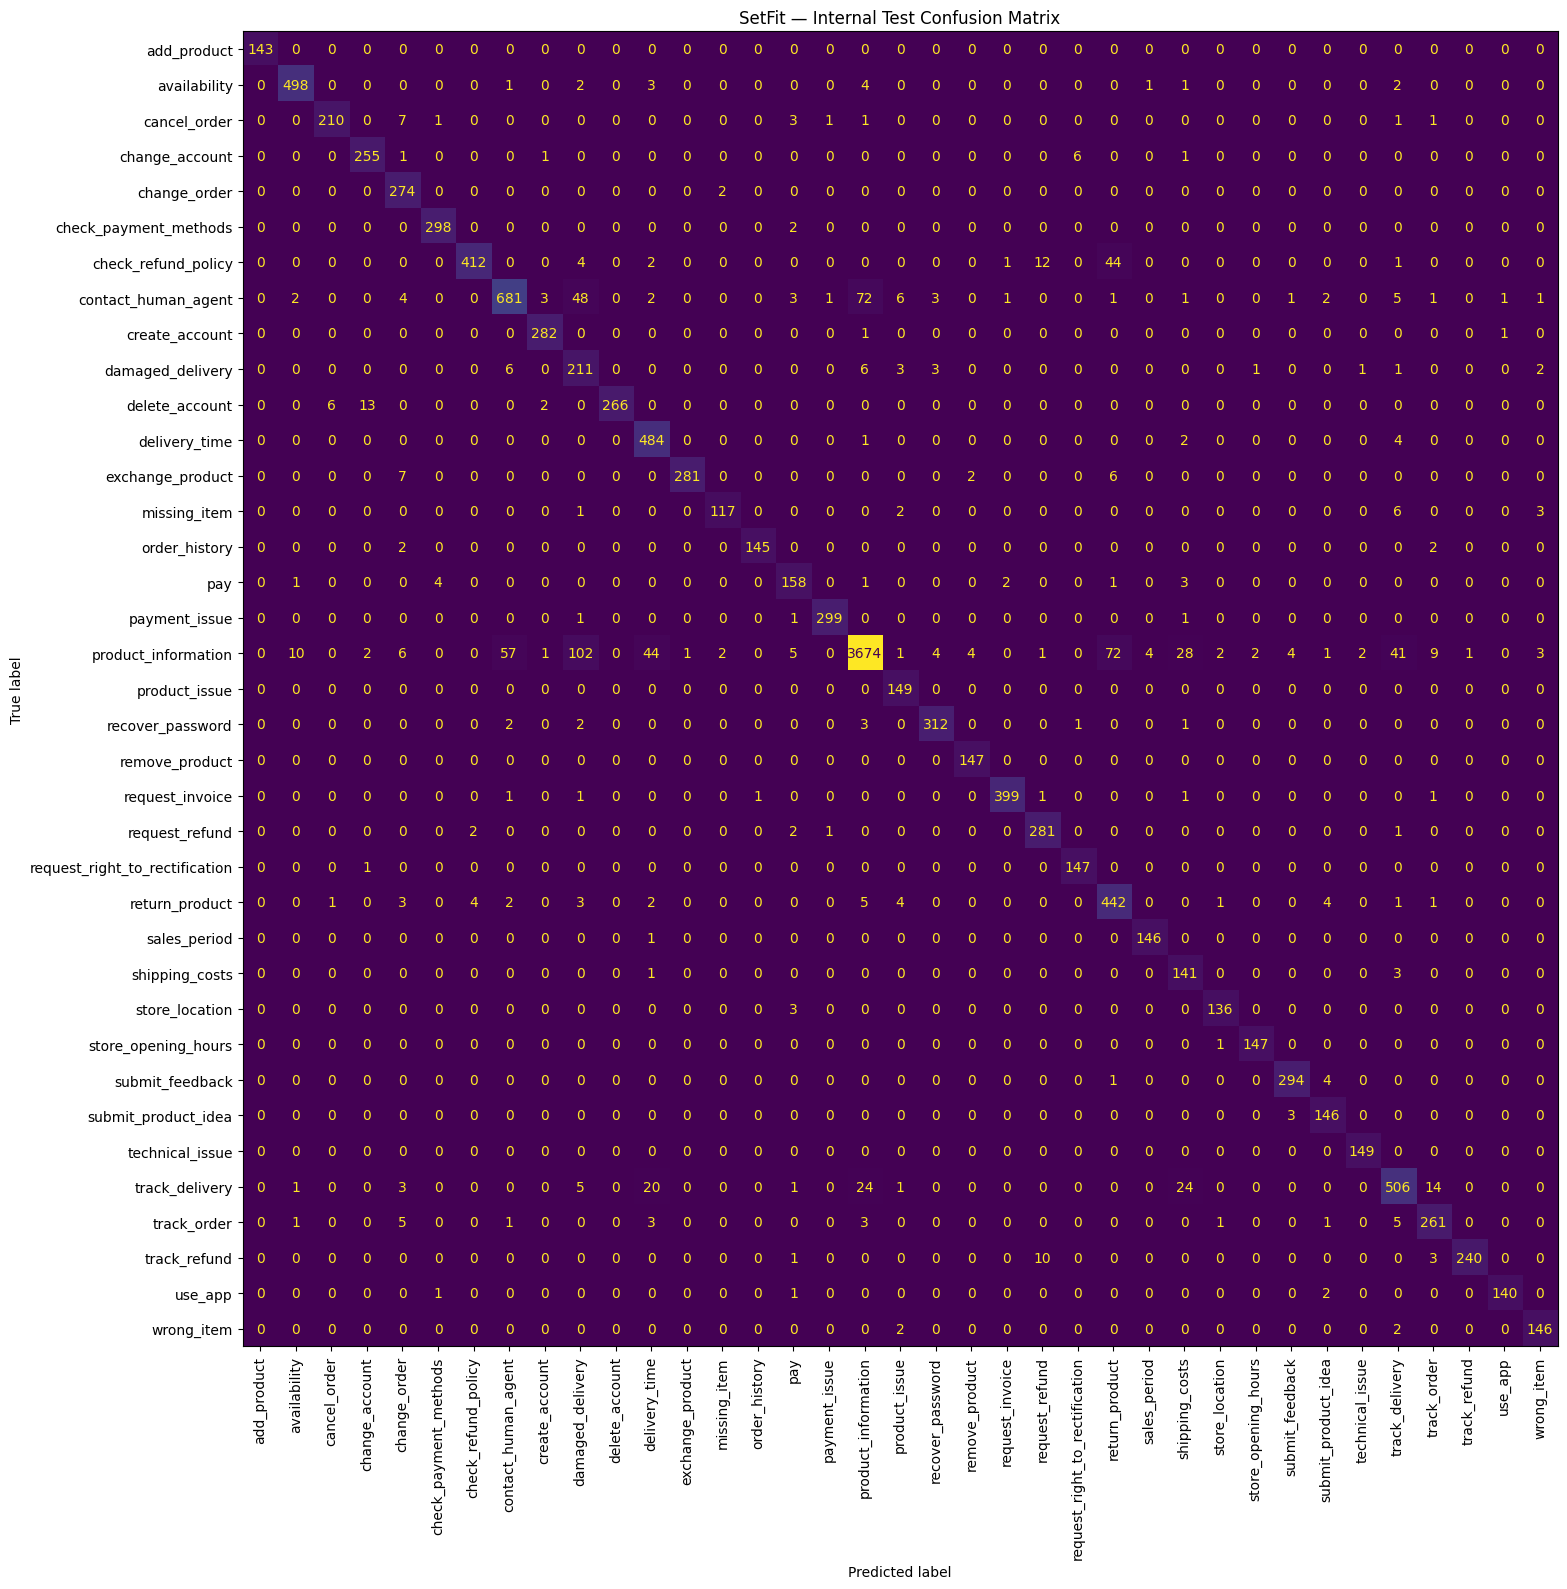

In [12]:
cm = confusion_matrix(y_true, y_pred, labels=sorted(ID2LABEL.keys()))

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("SetFit — Internal Test Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "internal_confusion_matrix.png", dpi=200)
plt.show()


## 9. Prediction and external evaluation helpers

In [13]:
def predict_texts_setfit(texts):
    pred_ids = setfit_predict_int_ids(texts)
    return [ID2LABEL[int(i)] for i in pred_ids]


def evaluate_external_dataset(external_df, text_col, external_intent_col, mapping, dataset_name):
    df = external_df.copy()
    df[text_col] = df[text_col].astype(str)
    df[external_intent_col] = df[external_intent_col].astype(str)

    df["mapped_intent"] = df[external_intent_col].map(mapping)
    df = df.dropna(subset=["mapped_intent"]).copy()
    df = df[df["mapped_intent"].isin(LABEL2ID)].copy()

    if df.empty:
        print(f"No mapped samples available for {dataset_name}. Update the mapping dictionary.")
        return None

    df["y_true"] = df["mapped_intent"]

    start_time = time.time()
    df["y_pred"] = predict_texts_setfit(df[text_col].tolist())
    inference_time_seconds = time.time() - start_time

    labels = sorted(df["y_true"].unique())

    metrics = {
        "dataset": dataset_name,
        "n_samples": int(len(df)),
        "accuracy": accuracy_score(df["y_true"], df["y_pred"]),
        "f1_macro": f1_score(df["y_true"], df["y_pred"], average="macro", zero_division=0),
        "f1_weighted": f1_score(df["y_true"], df["y_pred"], average="weighted", zero_division=0),
        "inference_time_seconds": inference_time_seconds,
    }

    print(metrics)

    report_txt = classification_report(
        df["y_true"],
        df["y_pred"],
        labels=labels,
        digits=4,
        zero_division=0,
    )

    print(report_txt)

    report_dict = classification_report(
        df["y_true"],
        df["y_pred"],
        labels=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    safe_name = dataset_name.lower().replace(" ", "_")

    df.to_csv(REPORTS_DIR / f"external_{safe_name}_predictions.csv", index=False, encoding="utf-8")

    pd.DataFrame(report_dict).transpose().to_csv(
        REPORTS_DIR / f"external_{safe_name}_classification_report.csv",
        encoding="utf-8",
    )

    with open(REPORTS_DIR / f"external_{safe_name}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    with open(REPORTS_DIR / f"external_{safe_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_txt)

    return {
        "metrics": metrics,
        "predictions": df,
        "report": report_txt,
    }


## 10. External evaluation — CLINC150

In [14]:
try:
    clinc = load_dataset("clinc_oos", "plus")
    clinc_test = clinc["test"].to_pandas()

    clinc_label_names = clinc["test"].features["intent"].names
    clinc_test["intent_name"] = clinc_test["intent"].apply(lambda x: clinc_label_names[int(x)])

    print("CLINC150 test shape:", clinc_test.shape)
    display(clinc_test[["text", "intent_name"]].head())
    display(clinc_test["intent_name"].value_counts().head(30).to_frame("n_samples"))

except Exception as e:
    print("Could not load CLINC150:", e)
    clinc_test = None


CLINC150 test shape: (5500, 3)


,text,intent_name
0,how would you say fly in italian,translate
1,what's the spanish word for pasta,translate
2,how would they say butter in zambia,translate
3,how do you say fast in spanish,translate
4,what's the word for trees in norway,translate


,n_samples
intent_name,
oos,1000
pin_change,30
account_blocked,30
what_song,30
international_fees,30
last_maintenance,30
meeting_schedule,30
ingredients_list,30
report_fraud,30


In [15]:
# Same mapping logic as DistilBERT.
# Keep only labels that exist in LABEL2ID.

CLINC_TO_PROJECT_INTENT = {
    "order_status": "track_order",
    "cancel": "cancel_order",
    "shopping_list": "product_information",
    "change_user_name": "change_account",
    "change_password": "recover_password",
    "reset_password": "recover_password",
    "store_hours": "store_opening_hours",
    "store_location": "store_location",
}

CLINC_TO_PROJECT_INTENT = {
    k: v for k, v in CLINC_TO_PROJECT_INTENT.items()
    if v is not None and v in LABEL2ID
}

print("Mapped CLINC intents:", CLINC_TO_PROJECT_INTENT)

if clinc_test is not None:
    clinc_results = evaluate_external_dataset(
        external_df=clinc_test,
        text_col="text",
        external_intent_col="intent_name",
        mapping=CLINC_TO_PROJECT_INTENT,
        dataset_name="CLINC150",
    )
else:
    clinc_results = None


Mapped CLINC intents: {'order_status': 'track_order', 'cancel': 'cancel_order', 'shopping_list': 'product_information', 'change_user_name': 'change_account', 'change_password': 'recover_password', 'reset_password': 'recover_password', 'store_hours': 'store_opening_hours', 'store_location': 'store_location'}
{'dataset': 'CLINC150', 'n_samples': 120, 'accuracy': 0.375, 'f1_macro': 0.10980500653211843, 'f1_weighted': 0.4666712777615033, 'inference_time_seconds': 0.4480006694793701}
                     precision    recall  f1-score   support

       cancel_order     1.0000    0.6333    0.7755        30
     change_account     0.8333    0.1667    0.2778        30
product_information     1.0000    0.1000    0.1818        30
        track_order     0.6667    0.6000    0.6316        30

          micro avg     0.8182    0.3750    0.5143       120
          macro avg     0.8750    0.3750    0.4667       120
       weighted avg     0.8750    0.3750    0.4667       120



## 11. External evaluation — Kaggle Ecommerce Intent

In [16]:
# Put your external Kaggle file in:
# data/splits/test_externe.csv
#
# Expected columns are detected automatically:
# text-like: utterance, text, query, sentence, customer_query, instruction
# intent-like: intent, label, category, intent_name

KAGGLE_PATH = DATA_DIR / "test_externe.csv"

if KAGGLE_PATH.exists():
    ecom_ext = pd.read_csv(KAGGLE_PATH)
    print("Kaggle external shape:", ecom_ext.shape)
    print(ecom_ext.columns.tolist())
    display(ecom_ext.head())
else:
    print("Missing file:", KAGGLE_PATH)
    ecom_ext = None


Kaggle external shape: (153464, 2)
['instructions', 'intents']


,instructions,intents
0,what do i need to do to change to the gold acc...,account_management
1,i try to modify the shippig address,account_management
2,how cani change order {{order number}}?,order_management
3,how could i enter afucking delivery address,account_management
4,can uhelp me canceling order {{order number}},order_management


In [17]:
if ecom_ext is not None:
    possible_text_cols = ["utterance", "text", "query", "sentence", "customer_query", "instructions"]
    possible_intent_cols = ["intents", "label", "category", "intent_name"]

    text_col = next((c for c in possible_text_cols if c in ecom_ext.columns), None)
    intent_col = next((c for c in possible_intent_cols if c in ecom_ext.columns), None)

    print("Detected text column:", text_col)
    print("Detected intent column:", intent_col)

    if text_col is None or intent_col is None:
        raise ValueError("Please manually set text_col and intent_col according to your CSV columns.")

    display(ecom_ext[intent_col].value_counts().to_frame("n_samples"))
else:
    text_col = None
    intent_col = None


Detected text column: instructions
Detected intent column: intents


,n_samples
intents,
issue_support,27799
order_tracking,17266
account_management,17083
product_inquiry,16151
order_management,9775
out_of_scope,9020
billing_and_payment,8949
place_order,8305
submit_feedback,6120


In [18]:
def normalize_placeholders(text):
    text = str(text)

    text = re.sub(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", " [EMAIL] ", text)
    text = re.sub(r"\b(?:\+?\d[\d\s\-().]{7,}\d)\b", " [PHONE] ", text)
    text = re.sub(r"\b(order|ord)[-_ ]?#?\d+\b", " [ORDER_ID] ", text, flags=re.I)
    text = re.sub(r"\b(invoice|bill|receipt)[-_ ]?#?\d+\b", " [BILL_ID] ", text, flags=re.I)
    text = re.sub(r"\$\s?\d+|\d+\s?(usd|eur|dt|tnd|£|€)", " [PRICE] ", text, flags=re.I)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " [DATE] ", text)
    text = re.sub(r"\b\d{4,}\b", " [NUMBER] ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


if ecom_ext is not None:
    ecom_ext["text_clean"] = ecom_ext[text_col].apply(normalize_placeholders)
    display(ecom_ext[[text_col, "text_clean", intent_col]].head(10))


,instructions,text_clean,intents
0,what do i need to do to change to the gold acc...,what do i need to do to change to the gold acc...,account_management
1,i try to modify the shippig address,i try to modify the shippig address,account_management
2,how cani change order {{order number}}?,how cani change order {{order number}}?,order_management
3,how could i enter afucking delivery address,how could i enter afucking delivery address,account_management
4,can uhelp me canceling order {{order number}},can uhelp me canceling order {{order number}},order_management
5,i need assistance to set the delivery address up,i need assistance to set the delivery address up,account_management
6,where to download invoice #00108?,where to download [BILL_ID] ?,billing_and_payment
7,i do not know how i could ask for goddamn refunds,i do not know how i could ask for goddamn refunds,issue_support
8,i do not know how to look for the bill from {{...,i do not know how to look for the bill from {{...,billing_and_payment
9,"i cannot remember my user key, i want to reset it","i cannot remember my user key, i want to reset it",account_management


In [19]:
if ecom_ext is not None:
    print("External intents:")
    print(sorted(ecom_ext[intent_col].astype(str).unique()))


External intents:
['account_management', 'add_to_cart', 'billing_and_payment', 'customer_care_support', 'delivery_options', 'issue_support', 'order_management', 'order_tracking', 'out_of_scope', 'place_order', 'product_inquiry', 'remove_from_cart', 'shipping_cost', 'store_information', 'submit_feedback']


In [20]:
KAGGLE_TO_PROJECT_INTENT = {
    "issue_support"       : "contact_human_agent",
    "order_tracking"      : "track_order",
    "account_management"  : "change_account",
    "product_inquiry"     : "product_information",   # was MISSING — biggest fix
    "order_management"    : "change_order",
    "billing_and_payment" : "check_payment_methods",
    "submit_feedback"     : "submit_feedback",
    "delivery_options"    : "track_delivery",
    "store_information"   : "store_location",
    "shipping_cost"       : "shipping_costs",
    "customer_care_support": "contact_human_agent",
}

KAGGLE_TO_PROJECT_INTENT = {
    k: v for k, v in KAGGLE_TO_PROJECT_INTENT.items()
    if v is not None and v in LABEL2ID
}

print("Final Kaggle mapping:", KAGGLE_TO_PROJECT_INTENT)


Final Kaggle mapping: {'issue_support': 'contact_human_agent', 'order_tracking': 'track_order', 'account_management': 'change_account', 'product_inquiry': 'product_information', 'order_management': 'change_order', 'billing_and_payment': 'check_payment_methods', 'submit_feedback': 'submit_feedback', 'delivery_options': 'track_delivery', 'store_information': 'store_location', 'shipping_cost': 'shipping_costs', 'customer_care_support': 'contact_human_agent'}


In [21]:
if ecom_ext is not None:
    kaggle_results = evaluate_external_dataset(
        external_df=ecom_ext,
        text_col="text_clean",
        external_intent_col=intent_col,
        mapping=KAGGLE_TO_PROJECT_INTENT,
        dataset_name="Kaggle_Ecommerce_Intent",
    )
else:
    kaggle_results = None


{'dataset': 'Kaggle_Ecommerce_Intent', 'n_samples': 125448, 'accuracy': 0.3239190740386455, 'f1_macro': 0.13076614019719496, 'f1_weighted': 0.41629088655790875, 'inference_time_seconds': 283.31014609336853}
                       precision    recall  f1-score   support

       change_account     0.9639    0.2155    0.3522     17083
         change_order     0.6490    0.3713    0.4723      9775
check_payment_methods     0.7808    0.2961    0.4294      8949
  contact_human_agent     0.6585    0.1304    0.2177     33467
  product_information     0.7706    0.4693    0.5833     16151
       shipping_costs     0.8457    0.8319    0.8387      5383
       store_location     0.8027    0.2326    0.3607      5438
      submit_feedback     0.9444    0.5270    0.6765      6120
       track_delivery     0.3261    0.7701    0.4581      5816
          track_order     0.8452    0.3060    0.4494     17266

            micro avg     0.6824    0.3239    0.4393    125448
            macro avg     0.7587   

## 12. Save SetFit model and mappings

In [22]:
BEST_MODEL_DIR = MODEL_DIR / "best_model"

model.save_pretrained(str(BEST_MODEL_DIR))

with open(MODEL_DIR / "label_mappings.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f, ensure_ascii=False, indent=2)

print("Saved SetFit model to:", BEST_MODEL_DIR)


Saved SetFit model to: ..\models\setfit_intent\best_model


## Comparison with DistilBERT

Use the files below to compare the two models:

SetFit:
- `reports/setfit_intent/internal_test_metrics.json`
- `reports/setfit_intent/internal_classification_report.csv`
- `reports/setfit_intent/external_clinc150_metrics.json`
- `reports/setfit_intent/external_kaggle_ecommerce_intent_metrics.json`

DistilBERT:
- `reports/distilbert_intent/internal_test_metrics.json`
- `reports/distilbert_intent/internal_classification_report.csv`
- `reports/distilbert_intent/external_clinc150_metrics.json`
- `reports/distilbert_intent/external_kaggle_ecommerce_intent_metrics.json`

Recommended comparison axes:
- internal accuracy
- internal macro F1
- external CLINC150 macro F1
- external Kaggle macro F1
- training time
- inference time
